<h3 style="text-align: center; background-color: #5AA647; color: white; padding: 8px; border-radius: 6px;">
CNN - Convolutional Neural Network
</h3>

##### Importing Libraries

In [1]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

#Evaluation library
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# Deep Learning libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Conv2D,MaxPooling2D,Flatten
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier

In [2]:
#Digit MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [3]:
x_train.shape # Print Number of input images , rows , columns for training set

(60000, 28, 28)

In [4]:
x_test.shape  # Print Number of input images , rows , columns for test set

(10000, 28, 28)

In [5]:
# change train data shape for CNN
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)

# change test data shape for CNN
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# set input image size (28x28, 1 color channel)
input_shape = (28, 28, 1)

In [6]:
# convert train data to decimal (float) values
x_train = x_train.astype('float32')

# convert test data to decimal (float) values
x_test = x_test.astype('float32')

In [7]:
# scale pixel values to range 0–1 for better learning
x_train /= 255

# scale test data the same way
x_test /= 255

In [8]:
# create a new CNN model (empty model to add layers step by step)
model = Sequential() ## It will execute in sequence means output of 1 will be the input to 2nd

# add convolution layer to detect features (edges, shapes)
model.add(Conv2D(28, kernel_size=(3,3), input_shape=input_shape))

# reduce image size and keep important parts
model.add(MaxPooling2D(pool_size=(2, 2)))

# convert 2D data to 1D list
model.add(Flatten())

# fully connected layer to learn patterns
model.add(Dense(128, activation=tf.nn.relu))

# turn off 20% neurons to avoid overfitting
model.add(Dropout(0.2))

# output layer: predict 1 out of 10 classes
model.add(Dense(10, activation=tf.nn.softmax))

C:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
#https://keras.io/api/optimizers/
# set optimizer, loss function, and evaluation metric
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# train the model using training data for 10 rounds (epochs)
model.fit(x=x_train, y=y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9378 - loss: 0.2049
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9760 - loss: 0.0798
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9829 - loss: 0.0548
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9865 - loss: 0.0412
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9892 - loss: 0.0324
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9911 - loss: 0.0267
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9926 - loss: 0.0219
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9932 - loss: 0.0203
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9931 - loss: 0.0201
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9941 - loss: 0.0172


In [10]:
# test the model on new (test) data and get loss & accuracy
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9832 - loss: 0.0665


[0.06649180501699448, 0.9832000136375427]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
6


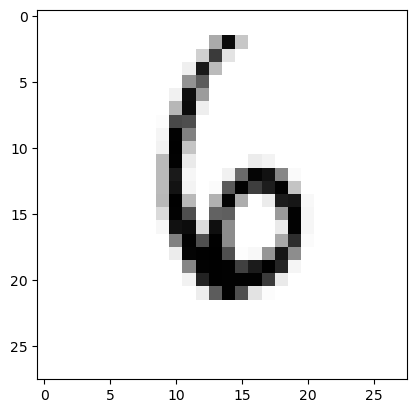

In [11]:
import matplotlib.pyplot as plt

# pick one image from test data
image_index = 6900

# show the image (28x28 grayscale)
plt.imshow(x_test[image_index].reshape(28, 28), cmap='Greys')

# reshape image (not really needed here)
predict = x_test[image_index].reshape(28, 28)

# predict the digit (model expects 4D input)
pred = model.predict(x_test[image_index].reshape(1, 28, 28, 1))

# print predicted class (0–9)
print(pred.argmax())

#### Create Confusion Matrix

In [12]:
from sklearn.metrics import confusion_matrix
import numpy as np

# get predictions from model
y_pred = model.predict(x_test)

# convert probabilities to class labels (0–9)
y_pred_classes = np.argmax(y_pred, axis=1)

# if y_test is not flat, convert it
y_true = y_test.flatten()

# create confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[ 972    0    0    0    0    1    3    2    2    0]
 [   0 1131    0    0    0    1    2    1    0    0]
 [   3    1 1014    1    0    0    2    9    1    1]
 [   1    0    2  992    0    2    0    6    3    4]
 [   1    0    4    0  968    0    2    0    0    7]
 [   2    1    1    7    0  870    5    1    0    5]
 [   3    3    2    0    1    1  947    0    1    0]
 [   0    3    7    0    1    0    0 1014    1    2]
 [   9    1    4    0    3    3    0    6  944    4]
 [   1    4    0    0   11    3    0    9    1  980]]


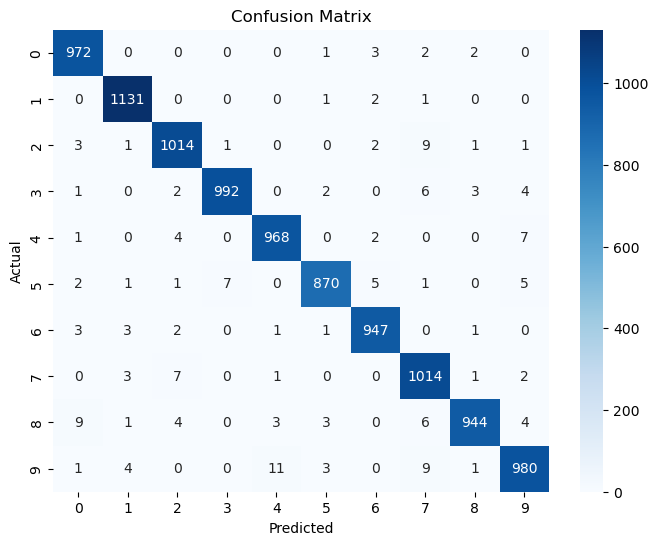

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### Classification Report

In [14]:
from sklearn.metrics import classification_report

# generate predictions
y_pred = model.predict(x_test)
y_pred_classes = y_pred.argmax(axis=1)

# true labels
y_true = y_test.flatten()

# print classification report
print(classification_report(y_true, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.98      0.99      1010
           4       0.98      0.99      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.97      0.99      0.98      1028
           8       0.99      0.97      0.98       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



#### Epoch Vs Training Accuracy

In [15]:
# train model and save history
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9949 - loss: 0.0147 - val_accuracy: 0.9833 - val_loss: 0.0733
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9949 - loss: 0.0147 - val_accuracy: 0.9835 - val_loss: 0.0733
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9959 - loss: 0.0127 - val_accuracy: 0.9834 - val_loss: 0.0739
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9955 - loss: 0.0132 - val_accuracy: 0.9851 - val_loss: 0.0728
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9951 - loss: 0.0150 - val_accuracy: 0.9836 - val_loss: 0.0749
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9962 - loss: 0.0109 - val_accuracy: 0.9854 - val_loss: 0.0724
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9957 - loss: 0.0115 - val_accuracy: 0.9840 - val_loss: 0.0832
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9958 - loss: 0

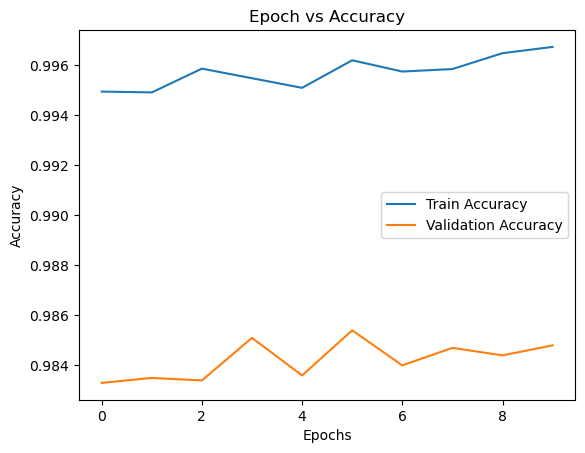

In [16]:
import matplotlib.pyplot as plt

# plot training accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')

# plot validation accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Epoch vs Accuracy')
plt.legend()

plt.show()